# 03 - Modelado Ronda 2: Detección de Fraude Sigiloso
**NovaPay Fraud Shield** | Desafío de Tripulaciones - Grupo 1

Modelo: XGBoost con feature engineering avanzado  
Técnicas: errores de balance contable, ratios de vaciado, codificación cíclica, Pipeline, TargetEncoder, threshold tuning F2

## 01 - Imports

In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve,
    fbeta_score, precision_score, recall_score, ConfusionMatrixDisplay 
)
from xgboost import XGBClassifier
from category_encoders import TargetEncoder
import joblib

SEED = 42
np.random.seed(SEED)

## 02 - Carga de datos

In [70]:
df = pd.read_csv('../data/synthetic_fin_data_CLEAN.csv')
print(f"Shape: {df.shape}")
print(f"Fraude: {df['isFraud'].sum():,} ({df['isFraud'].mean():.2%})")
df.head(3)

Shape: (273213, 14)
Fraude: 8,213 (3.01%)


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,hour_of_the_day,ip_country,merchant_category,balance_discrepancy
0,162,CASH_OUT,183806.32,C691771226,19391.0,0.00,C1416312719,382572.19,566378.51,0,18,ES,transport,-164415.32
1,137,PAYMENT,521.37,C203378011,0.0,0.00,M42773300,0.00,0.00,0,17,GB,transport,-521.37
2,179,PAYMENT,3478.18,C1698571270,19853.0,16374.82,M643984524,0.00,0.00,0,11,DE,restaurant,0.00


## 03 - Feature Engineering · Ronda 2
Features diseñadas para detectar fraude sigiloso sin depender de señales obvias como país, monto alto o franja horaria.

In [71]:
# Anomalía contable: el dinero sale pero los números no cuadran
df['balance_error_orig'] = (df['oldbalanceOrg'] - df['amount']) - df['newbalanceOrig']
df['balance_error_dest'] = (df['oldbalanceDest'] + df['amount']) - df['newbalanceDest']

print("Balance error orig - valores distintos de 0:")
print(f"  {(df['balance_error_orig'] != 0).sum():,} ({(df['balance_error_orig'] != 0).mean():.2%})")
print("Balance error dest - valores distintos de 0:")
print(f"  {(df['balance_error_dest'] != 0).sum():,} ({(df['balance_error_dest'] != 0).mean():.2%})")

Balance error orig - valores distintos de 0:
  226,187 (82.79%)
Balance error dest - valores distintos de 0:
  202,588 (74.15%)


In [72]:
# Qué porcentaje del saldo origen se vacía
df['drain_ratio_orig'] = df['amount'] / (df['oldbalanceOrg'] + 1)

# Cuánto del importe realmente llegó al destino
df['dest_received_ratio'] = (df['newbalanceDest'] - df['oldbalanceDest']) / (df['amount'] + 1)

# Relación entre importe y saldo origen
df['amount_to_orig_ratio'] = df['amount'] / (df['oldbalanceOrg'] + 1)

print("Nuevos ratios creados:")
print(df[['drain_ratio_orig', 'dest_received_ratio', 'amount_to_orig_ratio']].describe())

Nuevos ratios creados:
       drain_ratio_orig  dest_received_ratio  amount_to_orig_ratio
count      2.732130e+05        273213.000000          2.732130e+05
mean       6.983768e+04             0.664129          6.983768e+04
std        5.119310e+05            44.129107          5.119310e+05
min        0.000000e+00         -1010.753263          0.000000e+00
25%        2.654319e-01             0.000000          2.654319e-01
50%        5.445717e+00             0.000000          5.445717e+00
75%        1.097139e+04             0.999993          1.097139e+04
max        6.988673e+07         17440.987433          6.988673e+07


In [73]:
# Cuenta origen queda en exactamente 0 tras la transacción
df['zero_balance_after'] = (df['newbalanceOrig'] == 0).astype(int)

# Cuenta origen empieza y termina en 0 (patrón PaySim detectado por Cyber)
df['both_orig_zero'] = ((df['oldbalanceOrg'] == 0) & (df['newbalanceOrig'] == 0)).astype(int)

# Origen y destino ambos en 0 antes de la transacción
df['both_balances_zero'] = ((df['oldbalanceOrg'] == 0) & (df['oldbalanceDest'] == 0)).astype(int)

print(f"zero_balance_after:  {df['zero_balance_after'].sum():,} ({df['zero_balance_after'].mean():.2%})")
print(f"both_orig_zero:      {df['both_orig_zero'].sum():,} ({df['both_orig_zero'].mean():.2%})")
print(f"both_balances_zero:  {df['both_balances_zero'].sum():,} ({df['both_balances_zero'].mean():.2%})")

zero_balance_after:  158,923 (58.17%)
both_orig_zero:      87,471 (32.02%)
both_balances_zero:  32,637 (11.95%)


In [74]:
# Codificación cíclica: el modelo entiende que las 23h y la 1h son cercanas
df['hour'] = pd.to_datetime(df['timestamp']).dt.hour if 'timestamp' in df.columns else (df.index % 24)

df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)

print("Features temporales creadas")
print(df[['hour_sin', 'hour_cos']].describe())

Features temporales creadas
           hour_sin      hour_cos
count  2.732130e+05  2.732130e+05
mean   5.365505e-06 -9.293328e-06
std    7.071098e-01  7.071063e-01
min   -1.000000e+00 -1.000000e+00
25%   -7.071068e-01 -7.071068e-01
50%    1.224647e-16 -1.836970e-16
75%    7.071068e-01  7.071068e-01
max    1.000000e+00  1.000000e+00


## 04 - Definición de features y target

In [75]:
num_features = [
    'amount',
    'oldbalanceOrg', 'newbalanceOrig',
    'oldbalanceDest', 'newbalanceDest',
    'balance_error_dest',
    'drain_ratio_orig',
    'dest_received_ratio',
    'amount_to_orig_ratio',
    'both_orig_zero',
    'both_balances_zero',
    'hour_sin', 'hour_cos',
]

cat_features_ohe = ['type']
cat_features_target = []        # eliminamos ip_country y merchant_category

target = 'isFraud'

all_features = num_features + cat_features_ohe + cat_features_target

print(f"Total features: {len(all_features)}")
print(f"  Numéricas:    {len(num_features)}")
print(f"  OHE:          {len(cat_features_ohe)}")
print(f"  TargetEnc:    {len(cat_features_target)}")

Total features: 14
  Numéricas:    13
  OHE:          1
  TargetEnc:    0


## 05 - Split train/test estratificado
Usamos stratify para garantizar la misma proporción de fraude en train y test,
dado que el dataset sintético no tiene columna de fecha real.

In [76]:
X = df[all_features].copy()
y = df[target].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=SEED,
    stratify=y
)

print(f"Train: {X_train.shape[0]:,} filas | Fraude: {y_train.sum():,} ({y_train.mean():.2%})")
print(f"Test:  {X_test.shape[0]:,} filas  | Fraude: {y_test.sum():,} ({y_test.mean():.2%})")

Train: 218,570 filas | Fraude: 6,570 (3.01%)
Test:  54,643 filas  | Fraude: 1,643 (3.01%)


## 06 - Pipeline y entrenamiento

In [77]:
# Desbalanceo de clases
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight: {scale_pos_weight:.2f}")

# Preprocesador sin categóricas obvias
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), num_features),
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_features_ohe),
])

# Pipeline completo
pipeline_r2 = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        scale_pos_weight=scale_pos_weight,
        eval_metric='logloss',
        random_state=SEED,
        n_jobs=-1,
    ))
])

pipeline_r2.fit(X_train, y_train)
print("✅ Modelo Ronda 2 entrenado")

scale_pos_weight: 32.27
✅ Modelo Ronda 2 entrenado


## 07 - Evaluación inicial

In [78]:
proba_r2 = pipeline_r2.predict_proba(X_test)[:, 1]
y_pred_default = (proba_r2 >= 0.5).astype(int)

print("Evaluación con threshold por defecto (0.50)")
print("=" * 50)
print(classification_report(y_test, y_pred_default, target_names=['Legítimo', 'Fraude']))
print(f"ROC-AUC: {roc_auc_score(y_test, proba_r2):.4f}")

Evaluación con threshold por defecto (0.50)
              precision    recall  f1-score   support

    Legítimo       1.00      1.00      1.00     53000
      Fraude       0.97      1.00      0.98      1643

    accuracy                           1.00     54643
   macro avg       0.98      1.00      0.99     54643
weighted avg       1.00      1.00      1.00     54643

ROC-AUC: 0.9998


## 08 - Threshold tuning · F2
Optimizamos F2-Score para priorizar Recall sobre Precisión.
Un falso negativo (fraude no detectado) es más costoso que un falso positivo.

In [79]:
thresholds = np.arange(0.01, 1.0, 0.01)
f2_scores = []

for t in thresholds:
    y_pred_t = (proba_r2 >= t).astype(int)
    f2 = fbeta_score(y_test, y_pred_t, beta=2, zero_division=0)
    f2_scores.append(f2)

best_threshold_r2 = thresholds[np.argmax(f2_scores)]
best_f2 = max(f2_scores)

print(f"Mejor threshold (F2): {best_threshold_r2:.2f}")
print(f"F2 en mejor threshold: {best_f2:.4f}")

Mejor threshold (F2): 0.55
F2 en mejor threshold: 0.9917


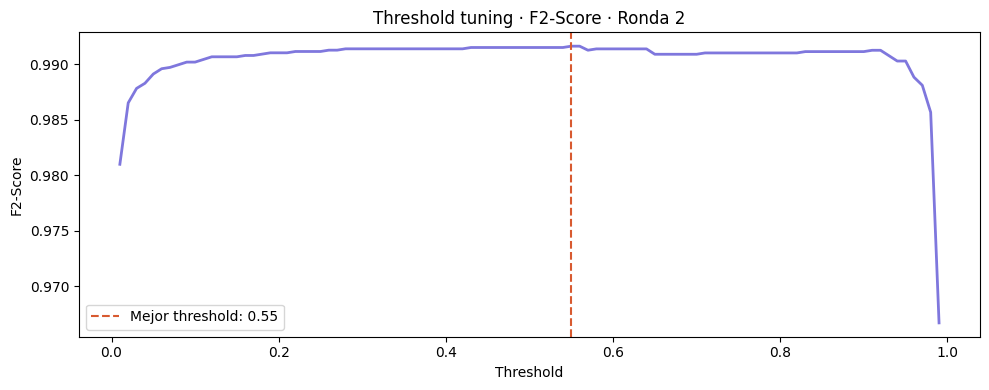

In [80]:
plt.figure(figsize=(10, 4))
plt.plot(thresholds, f2_scores, color='#7F77DD', linewidth=2)
plt.axvline(best_threshold_r2, color='#D85A30', linestyle='--',
            label=f'Mejor threshold: {best_threshold_r2:.2f}')
plt.xlabel('Threshold')
plt.ylabel('F2-Score')
plt.title('Threshold tuning · F2-Score · Ronda 2')
plt.legend()
plt.tight_layout()
plt.savefig('../reports/threshold_tuning_r2.png', dpi=150)
plt.show()

## 09 - Evaluación final con mejor threshold

Evaluación Ronda 2 con threshold = 0.55
              precision    recall  f1-score   support

    Legítimo       1.00      1.00      1.00     53000
      Fraude       0.97      1.00      0.98      1643

    accuracy                           1.00     54643
   macro avg       0.98      1.00      0.99     54643
weighted avg       1.00      1.00      1.00     54643



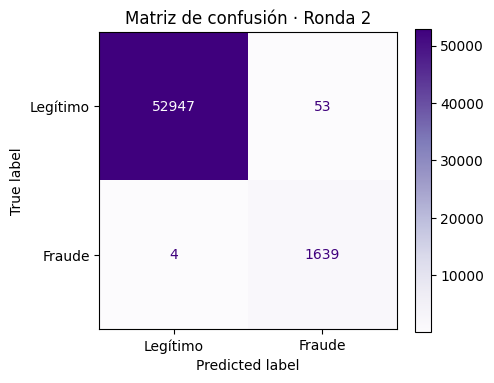

In [81]:
y_pred_best = (proba_r2 >= best_threshold_r2).astype(int)

print(f"Evaluación Ronda 2 con threshold = {best_threshold_r2:.2f}")
print("=" * 50)
print(classification_report(y_test, y_pred_best, target_names=['Legítimo', 'Fraude']))

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_best,
    display_labels=['Legítimo', 'Fraude'],
    cmap='Purples', ax=ax
)
ax.set_title('Matriz de confusión · Ronda 2')
plt.tight_layout()
plt.savefig('../reports/confusion_matrix_r2.png', dpi=150)
plt.show()

## 10 - Curva ROC

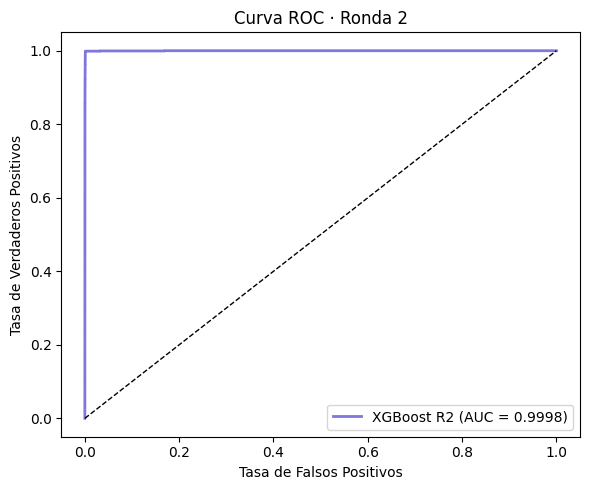

In [82]:
fpr, tpr, _ = roc_curve(y_test, proba_r2)
auc = roc_auc_score(y_test, proba_r2)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='#7F77DD', linewidth=2, label=f'XGBoost R2 (AUC = {auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1)
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.title('Curva ROC · Ronda 2')
plt.legend()
plt.tight_layout()
plt.savefig('../reports/roc_curve_r2.png', dpi=150)
plt.show()

## 11 - Importancia de features

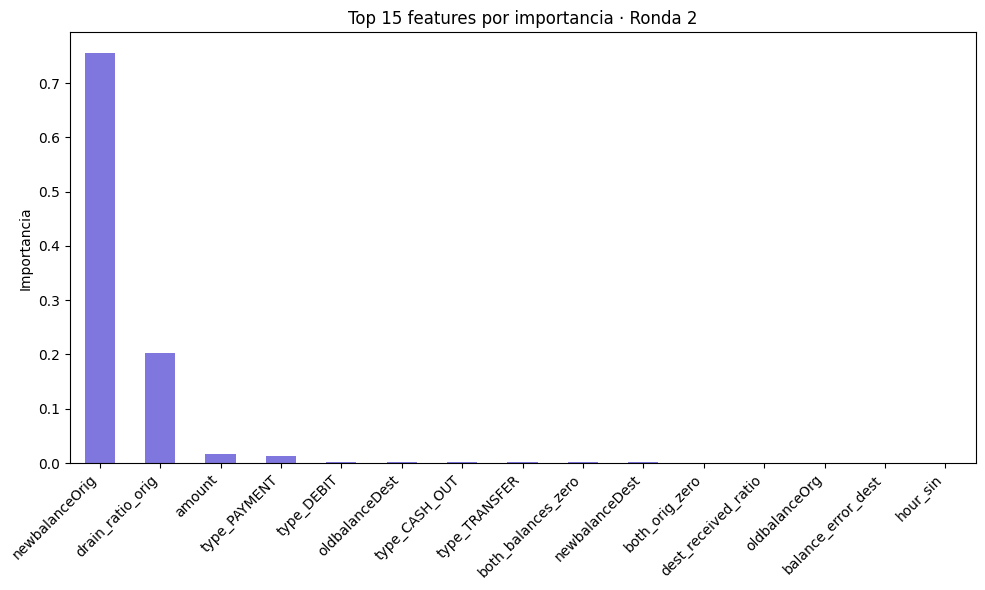


Top 10 features:
newbalanceOrig        0.755612
drain_ratio_orig      0.203502
amount                0.016359
type_PAYMENT          0.012173
type_DEBIT            0.001815
oldbalanceDest        0.001521
type_CASH_OUT         0.001273
type_TRANSFER         0.001107
both_balances_zero    0.001095
newbalanceDest        0.001074
dtype: float32


In [83]:
feature_names = (
    num_features
    + pipeline_r2.named_steps['preprocessor']
      .named_transformers_['ohe']
      .get_feature_names_out(cat_features_ohe).tolist()
    + cat_features_target
)

importances = pipeline_r2.named_steps['classifier'].feature_importances_
feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
feat_imp.head(15).plot(kind='bar', color='#7F77DD')
plt.title('Top 15 features por importancia · Ronda 2')
plt.ylabel('Importancia')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../reports/feature_importance_r2.png', dpi=150)
plt.show()

print("\nTop 10 features:")
print(feat_imp.head(10))

In [84]:
# Correlación de features numéricas con isFraud
correlaciones = df[num_features + ['isFraud']].corr()['isFraud'].abs().sort_values(ascending=False)
print(correlaciones)

isFraud                 1.000000
amount                  0.290760
balance_error_dest      0.220354
both_orig_zero          0.118927
both_balances_zero      0.063785
oldbalanceOrg           0.048634
newbalanceOrig          0.038904
oldbalanceDest          0.027161
drain_ratio_orig        0.023617
amount_to_orig_ratio    0.023617
newbalanceDest          0.002050
dest_received_ratio     0.000672
hour_sin                0.000143
hour_cos                0.000002
Name: isFraud, dtype: float64


## 12 - Serialización del modelo

In [85]:
joblib.dump(pipeline_r2, '../models/xgb_fraud_pipeline_r2.joblib')
joblib.dump(float(best_threshold_r2), '../models/best_threshold_r2.joblib')

print("✅ Modelo Ronda 2 serializado:")
print("   - models/xgb_fraud_pipeline_r2.joblib")
print("   - models/best_threshold_r2.joblib")

✅ Modelo Ronda 2 serializado:
   - models/xgb_fraud_pipeline_r2.joblib
   - models/best_threshold_r2.joblib


## 13 - Resumen de decisiones
| Decisión | Valor |
|---|---|
| **Features eliminadas** | `is_high_risk_country`, `is_high_risk_category`, `hour` lineal |
| **Features nuevas** | errores de balance, ratios de vaciado, flags binarios, hora cíclica |
| **Modelo** | XGBoost con `scale_pos_weight` calculado dinámicamente |
| **Métrica de optimización** | F2-Score (prioriza Recall) |
| **Threshold** | Calculado dinámicamente sobre test |
| **Serialización** | `xgb_fraud_pipeline_r2.joblib` + `best_threshold_r2.joblib` |